# <a id='toc1_'></a>[Basic Root Locus design](#toc0_)

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

# <a id='toc2_'></a>[Design 9-17](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Basic Root Locus design](#toc1_)    
- [Design 9-17](#toc2_)    
- [Design 9-25](#toc3_)    
- [Design 9-24](#toc4_)    
- [RL design using angles](#toc5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

Closed Loop Poles at: -20.25+0.00j, -1.00+2.00j, -1.00-2.00j


<IPython.core.display.Math object>

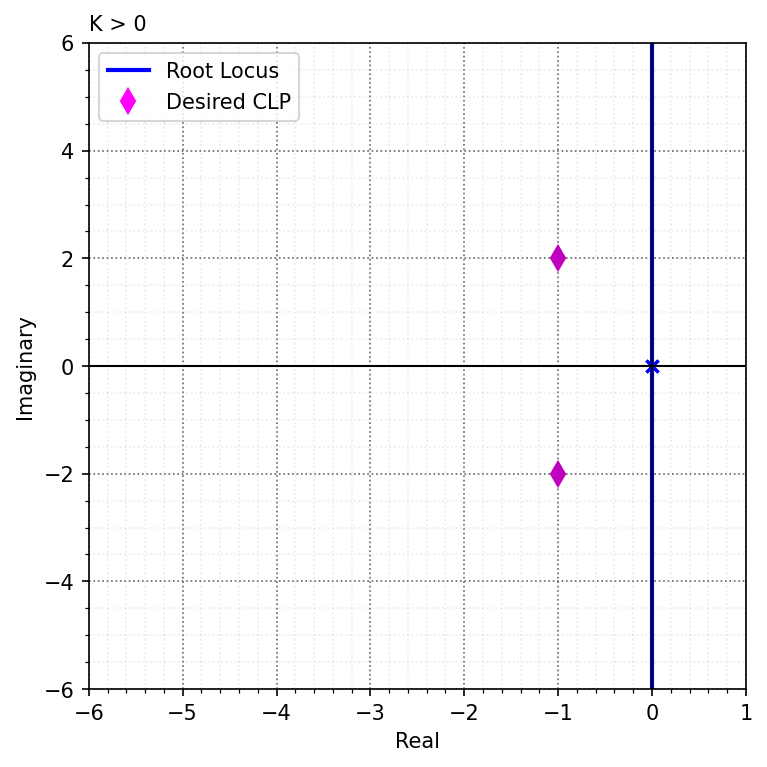

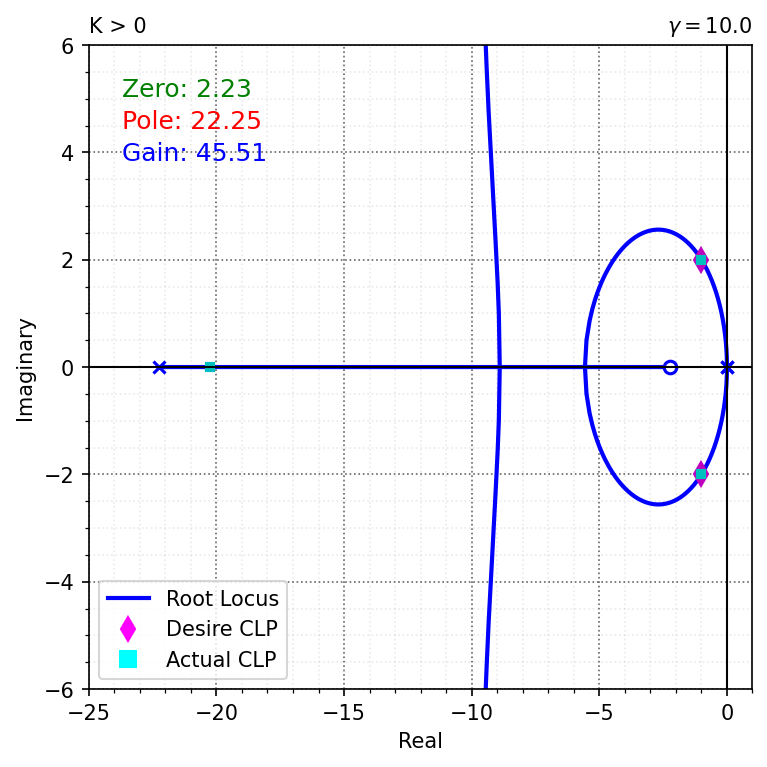

In [4]:
s_target = complex(-1,2)
gamma = 10 # p/z ratio

G = ct.tf((0,1), np.convolve((1,0),(1,0)))
Gc, scl = cm.Root_Locus_design_ratio(G,s_target = s_target, z0 = np.array([2]), gamma = gamma,verbose=False)
L = G*Gc

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(G,np.logspace(-3, 100, num=1500),verbose=True)
ct.rlocus(G, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',ms=8)
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.set_xlim((-6,1))
ax.set_ylim([-6, 6])
plt.xlabel('Real')
plt.ylabel('Imaginary')

# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='magenta', marker='d', markersize=8, linestyle='None'),
]
# Add legend with custom handles
ax.legend(custom_lines, ['Root Locus', 'Desired CLP', ])

bm.nicegrid(ax)
plt.title('K > 0',loc='left')
plt.savefig("./figs/Ex9_17a.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(L,np.logspace(-3, 1, num=1500),verbose=True)
ct.rlocus(L, gains=klist,color='b',ax=ax)

ax.plot(s_target.real,s_target.imag,'md',ms=8)
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.plot(scl.real,scl.imag,'cs',ms=4)
ax.plot(scl.real,-scl.imag,'cs',ms=4)
plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.title('K > 0',loc='left')
plt.title(r'$\gamma={:3.1f}$'.format(gamma),loc='right')
ax.plot(np.real(-Gc.zeros()), np.imag(-Gc.zeros()), 'go', ms=8, label='Compensator Zero')
ax.plot(np.real(-Gc.poles()), np.imag(-Gc.poles()), 'rx', ms=8, label='Compensator Pole')

ax.text(0.05, 0.95, f'Zero: {np.real(-Gc.zeros())[0]:.2f}', transform=ax.transAxes, fontsize=12, color='green', verticalalignment='top')
ax.text(0.05, 0.90, f'Pole: {np.real(-Gc.poles())[0]:.2f}', transform=ax.transAxes, fontsize=12, color='red', verticalalignment='top')
ax.text(0.05, 0.85, f'Gain: {Gc.num[0][0][0]/Gc.den[0][0][0]:.2f}', transform=ax.transAxes, fontsize=12, color='blue', verticalalignment='top')

ax.set_xlim((-(np.ceil(-np.real(Gc.poles())[0] / 5) * 5), 1))
ax.set_ylim([-6, 6])

# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='magenta', marker='d', markersize=8, linestyle='None'),
    Line2D([0], [0], color='cyan', marker='s', markersize=8, linestyle='None'),
]
# Add legend with custom handles
ax.legend(custom_lines, ['Root Locus', 'Desire CLP', 'Actual CLP', ])

plt.savefig("./figs/Ex9_17.pdf", dpi=600)
bm.nicegrid(ax)
print('Closed Loop Poles at: '+', '.join('{:.2f}'.format(s) for s in scl))
cm.show_tf_latex(Gc)

# <a id='toc3_'></a>[Design 9-25](#toc0_)

Phase from G -243.43
Phase from Gc zero 90.00
Phase required 26.57
Closed Loop Poles at: -4.00+0.00j, -2.00+2.00j, -2.00-2.00j


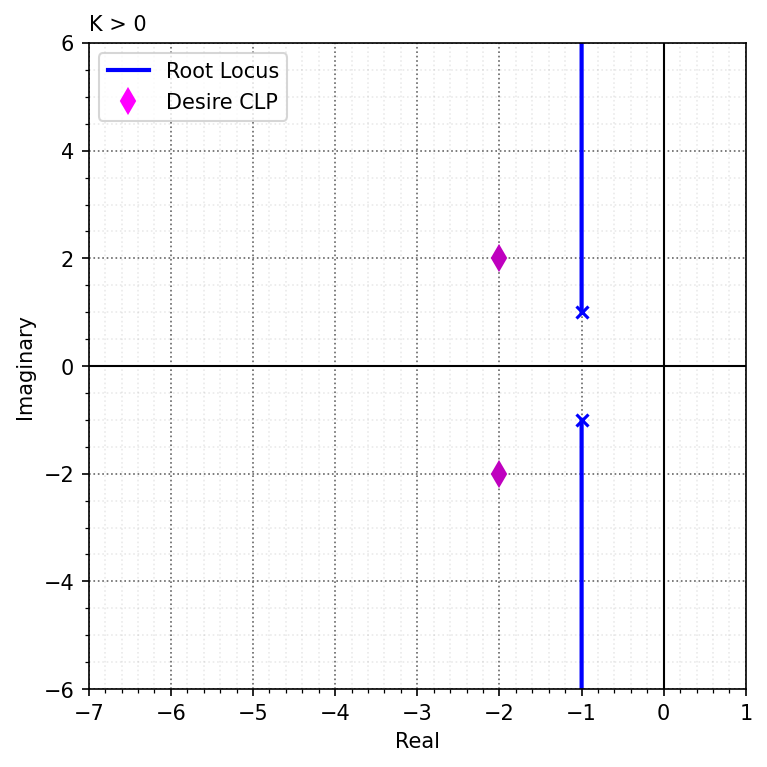

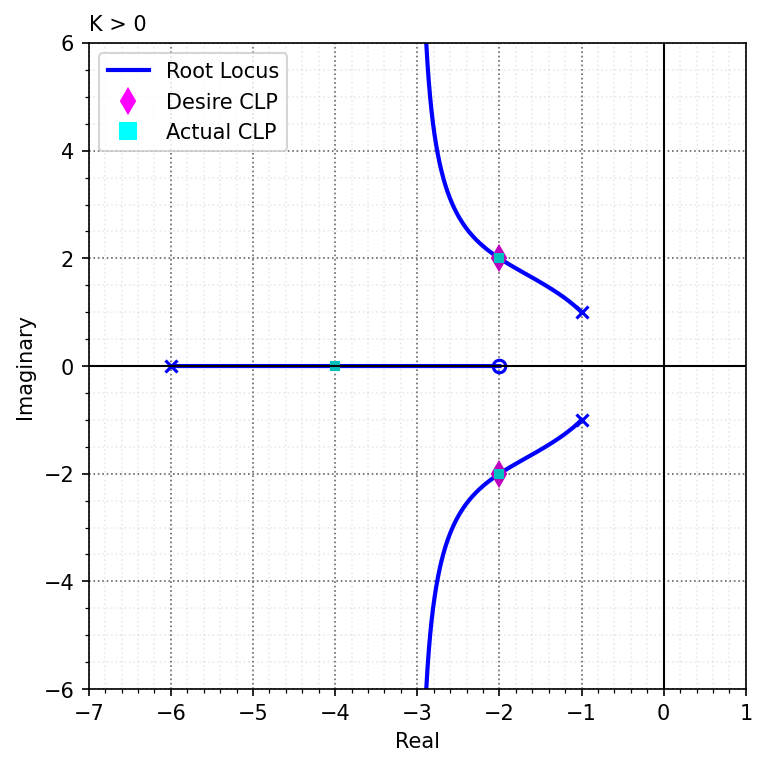

In [5]:
s_target=complex(-2,2)
#
G = ct.tf((0,1), (1,2,2))
Gc, scl = cm.Root_Locus_design_cancel(G,s_cancel = -2, s_target = s_target)
L = G*Gc

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist = cm.Root_Locus_gains(G)
rl = ct.rlocus(G, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',ms=8)
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
plt.xlim((-7,1))
ax.set_ylim([-6, 6])
plt.title('K > 0',loc='left')
plt.xlabel('Real')
plt.ylabel('Imaginary')

from matplotlib.lines import Line2D
# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='magenta', marker='d', markersize=8, linestyle='None'),
]
# Add legend with custom handles
ax.legend(custom_lines, ['Root Locus', 'Desire CLP', ])

bm.nicegrid(ax)
plt.savefig("./figs/Ex9_23a.pdf", dpi=600)

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist = cm.Root_Locus_gains(L)
rl = ct.rlocus(L, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',ms=8)
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.plot(scl.real,scl.imag,'cs',ms=4)
plt.xlim((-7,1))
ax.set_ylim([-6, 6])
plt.title('K > 0',loc='left')
plt.xlabel('Real')
plt.ylabel('Imaginary')
bm.nicegrid(ax)
plt.savefig("./figs/Ex9_23.pdf", dpi=600)

# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='magenta', marker='d', markersize=8, linestyle='None'),
    Line2D([0], [0], color='cyan', marker='s', markersize=8, linestyle='None'),
]
# Add legend with custom handles
ax.legend(custom_lines, ['Root Locus', 'Desire CLP', 'Actual CLP', ])
plt.savefig("./figs/Ex9_23.pdf", dpi=600)

print('Closed Loop Poles at: '+', '.join('{:.2f}'.format(s) for s in scl))
Gc

def writefile(filename, Gc):
    with open(filename+"_zero.txt", "w") as f:
        f.write(str(f"{np.real(-Gc.zeros())[0]:4.2f}"))
    with open(filename+"_pole.txt", "w") as f:
        f.write(str(f"{np.real(-Gc.poles())[0]:4.2f}"))
    with open(filename+"_gain.txt", "w") as f:
        gain = Gc.num[0][0]/Gc.den[0][0]
        f.write(str(f"{gain[0]:4.2f}"))

source = "./"        
cm.writeGc(source+"Gc_9_25", Gc)

# <a id='toc4_'></a>[Design 9-24](#toc0_)

Closed Loop Poles at: -1.00+2.00j, -1.00-2.00j, -0.25+0.00j


<IPython.core.display.Math object>

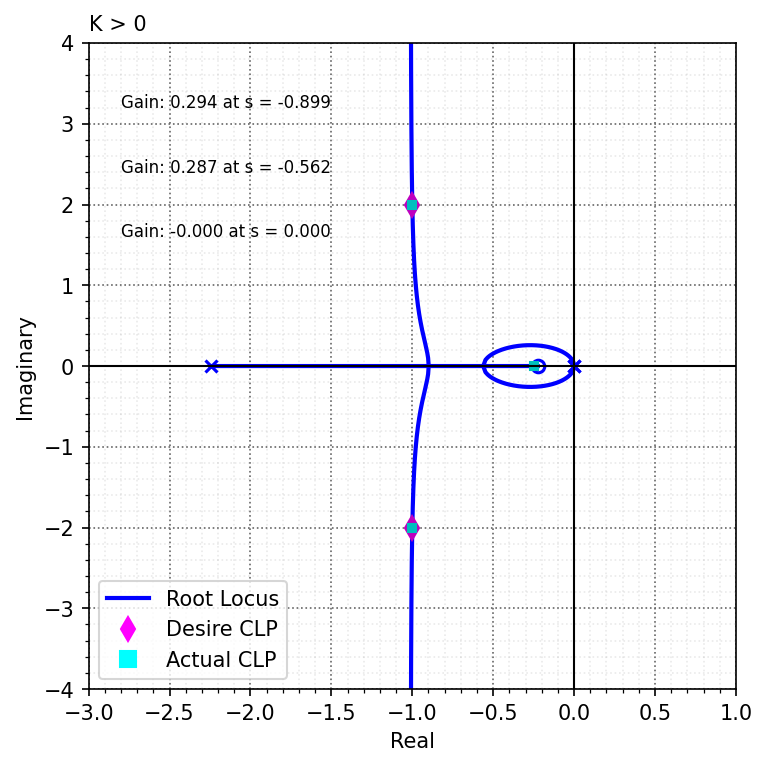

In [6]:
from sympy import symbols, solve
K,alp,z,p = symbols('K alp z p')

#System
G = ct.tf((0,1), (1,0,0))
#Pole Placement
s_targ = complex(-1,2)

gamma = 10
p = gamma*z

# closed-loop char eq will be desired poles and alp, which is unknown
phi_d = np.convolve(np.convolve((1,-s_targ),(1,np.conjugate(-s_targ))),(1,alp))
# form L_den+KL_num to find actual char eq
phi_c = np.convolve(np.squeeze(G.den),[1,p]) + K*np.convolve(np.squeeze(G.num),(0,0,1,z))

# equate the two char eq and solve for the parms of the controller
func = [phi_d[x]-phi_c[x] for x in range(1,4)]
sol = solve(func,(z,alp,K))
sol_z, sol_alp, sol_K = [float(sol[0][x]) for x in range(3)]

Gc = sol_K * ct.tf((1,sol_z), (1,gamma*sol_z))
L = G*Gc
Gcl = ct.feedback(L,1)
scl = Gcl.poles()
print('Closed Loop Poles at: '+', '.join('{:.2f}'.format(s) for s in scl))

fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(L, verbose=True)
rl = ct.rlocus(L, gains=klist, color='b', ax=ax)
ax.plot(np.real(s_targ),np.imag(s_targ),'md',ms=8)
ax.plot(np.real(s_targ),np.imag(-s_targ),'md',ms=8)
ax.plot(scl.real,scl.imag,'cs',ms=4)
ax.set_xlim([-3, 1]);ax.set_ylim([-4, 4])
bm.nicegrid(ax)
plt.xlabel('Real')
plt.ylabel('Imaginary')
ax.set_title('K > 0',loc='left')
cm.add_break_info(ax, break_info)

# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='magenta', marker='d', markersize=8, linestyle='None'),
    Line2D([0], [0], color='cyan', marker='s', markersize=8, linestyle='None'),
]
# Add legend with custom handles
ax.legend(custom_lines, ['Root Locus', 'Desire CLP', 'Actual CLP', ])

plt.savefig("./figs/Ex9_24.pdf", dpi=600)

with open(source+"Gc_9_24_zero.txt", "w") as f:
    f.write(str(f"{np.real(-Gc.zeros())[0]:4.2f}"))
with open(source+"Gc_9_24_pole.txt", "w") as f:
    f.write(str(f"{np.real(-Gc.poles())[0]:4.2f}"))
with open(source+"Gc_9_24_gain.txt", "w") as f:
    gain = Gc.num[0][0]/Gc.den[0][0]
    f.write(str(f"{gain[0]:4.2f}"))
    
cm.show_tf_latex(Gc)

# <a id='toc5_'></a>[RL design using angles](#toc0_)

Phase from G -206.57
Phase from Gc zero 90.00
Phase required 63.43
Closed Loop Poles at: -1.00+2.00j, -1.00-2.00j, -1.00+0.00j


<IPython.core.display.Math object>

<IPython.core.display.Math object>

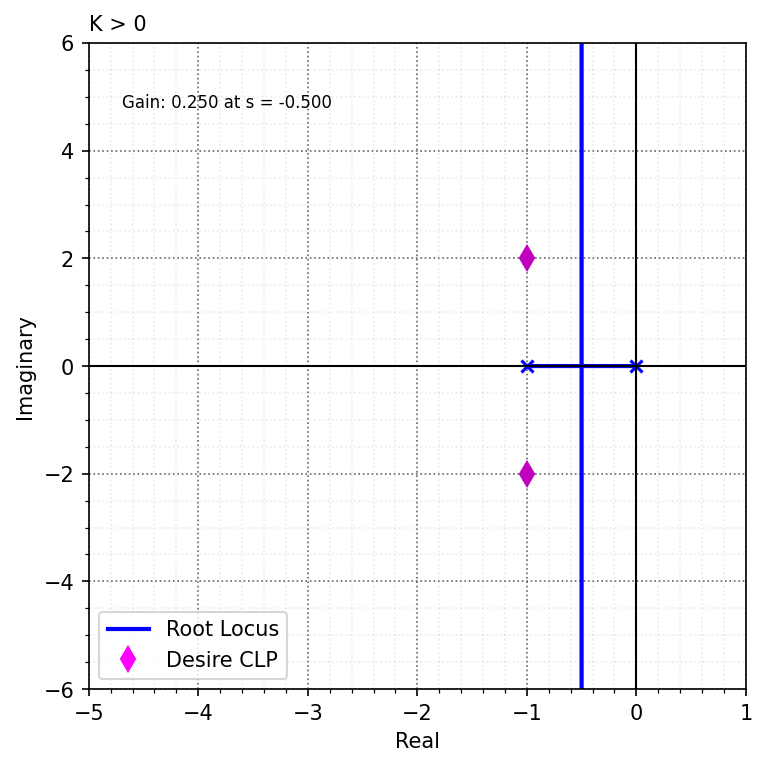

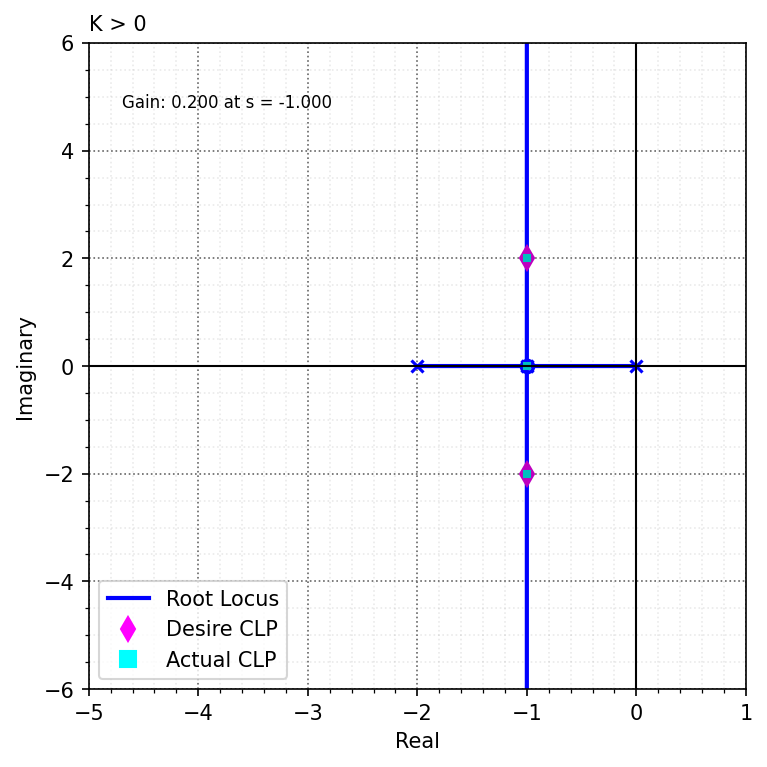

In [7]:
# G_c(s) = K(s+z)/(s+p)

s_target = complex(-1,2)
G = ct.tf((0,1), np.convolve((1,0),(1, 1)))
Gc, scl = cm.Root_Locus_design_cancel(G,s_target = s_target)
L = G*Gc
print('Closed Loop Poles at: '+', '.join('{:.2f}'.format(s) for s in scl))
display(cm.show_tf_latex(G,"G"))
display(cm.show_tf_latex(Gc,"Gc"))

###################
# G
###################
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(G,verbose=True)
rl = ct.rlocus(G, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',ms=8,label='Target')
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.set_xlim((-5,1))
ax.set_ylim([-6, 6])
plt.title('K > 0',loc='left')
bm.nicegrid(ax)
cm.add_break_info(ax, break_info)

# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='magenta', marker='d', markersize=8, linestyle='None'),
]
# Add legend with custom handles
ax.legend(custom_lines, ['Root Locus', 'Desire CLP' ])

plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.savefig("./figs/Ex9_18a.pdf", dpi=600)

###################
# L
###################
fig, ax = plt.subplots(1,figsize=(5, 5),dpi=150,constrained_layout = True)
klist, break_info = cm.Root_Locus_gains(L, verbose=True)    
rl = ct.rlocus(L, gains=klist,color='b',ax=ax)
ax.plot(s_target.real,s_target.imag,'md',label='Target',ms=8)
ax.plot(s_target.real,-s_target.imag,'md',ms=8)
ax.plot(scl.real,scl.imag,'cs',ms=3,label='closed loop poles')
ax.set_xlim((-5,1))
ax.set_ylim([-6, 6])
plt.title('K > 0',loc='left')
bm.nicegrid(ax)
cm.add_break_info(ax, break_info)

# Create custom legend handles
custom_lines = [
    Line2D([0], [0], color='blue', lw=2, linestyle='-'),
    Line2D([0], [0], color='magenta', marker='d', markersize=8, linestyle='None'),
    Line2D([0], [0], color='cyan', marker='s', markersize=8, linestyle='None'),
]
# Add legend with custom handles
ax.legend(custom_lines, ['Root Locus', 'Desire CLP', 'Actual CLP', ])

plt.xlabel('Real')
plt.ylabel('Imaginary')
plt.savefig("./figs/Ex9_18.pdf", dpi=600)